# Similarity metrics

In [2]:
import math
import random
import warnings
warnings.filterwarnings("ignore")

from datetime import datetime, timedelta

import numpy as np
import pandas as pd

import plotly.graph_objects as go
import plotly.io as pio
pio.renderers.default = "notebook"

import similaritymeasures
from sdtw.soft_dtw import SoftDTW

## Data loading

In [3]:
df = pd.read_csv("hsa_state_new.csv", parse_dates=["time_value"])
df = df.dropna(subset=["state", "hsa_value", "state_value"])
df = df.sort_values(["hsa_id", "time_value"]).reset_index(drop=True)

print(f"Rows       : {len(df):,}")
print(f"States     : {df['state'].nunique()}")
print(f"HSAs       : {df['hsa_id'].nunique()}")
print(f"Date range : {df['time_value'].min().date()} to {df['time_value'].max().date()}")
df.head()

Rows       : 125,839
States     : 38
HSAs       : 671
Date range : 2022-09-25 to 2026-05-17


,time_value,hsa_id,state,hsa_value,state_value,hsa_pop,state_pop,pop_ratio
0,2022-09-25,1,Maryland,0.00,0.26,96475.0,6170738.0,0.015634
1,2022-10-02,1,Maryland,0.00,0.41,96475.0,6170738.0,0.015634
2,2022-10-09,1,Maryland,0.00,0.93,96475.0,6170738.0,0.015634
3,2022-10-16,1,Maryland,0.19,1.80,96475.0,6170738.0,0.015634
4,2022-10-23,1,Maryland,0.70,3.74,96475.0,6170738.0,0.015634


In [45]:
hsa_list = df["hsa_id"].values
chosen_id = random.choice(hsa_list)

hsa_display = df[df['hsa_id'] == chosen_id]

dates = hsa_display["time_value"].values
hsa_curve = hsa_display["hsa_value"].values
state_curve = hsa_display["state_value"].values

fig = go.Figure()
fig.add_trace(go.Scatter(x=dates, y=hsa_curve, name='HSA'))
fig.add_trace(go.Scatter(x=dates, y=state_curve, name='State'))
fig.update_layout(title=f"HSA {chosen_id} ({hsa_display['state'].iloc[0]})")
fig.update_xaxes(dtick="M1")
fig.show()

## Helper functions

In [5]:
def make_curve(t_days, values):
    curve = np.zeros((len(t_days), 2))
    curve[:, 0] = t_days
    curve[:, 1] = values
    return curve

print("Helpers ready")

Helpers ready


## HSA analysis
### Season specification

In [52]:
season = np.zeros(len(df), dtype=int)
date = df["time_value"]

ranges = [
    (1, pd.Timestamp("2022-10-01"), pd.Timestamp("2023-02-28")),
    (2, pd.Timestamp("2023-10-01"), pd.Timestamp("2024-05-31")),
    (3, pd.Timestamp("2024-11-01"), pd.Timestamp("2025-05-31")),
    (4, pd.Timestamp("2025-11-01"), pd.Timestamp("2026-05-31")),
]

for label, start, end in ranges:
    mask = (date >= start) & (date <= end)
    season[mask] = label

df["season"] = season

df_clean = df[df["season"] != 0].copy()
df_clean["season"].value_counts().sort_index()

season
1    14762
2    23485
3    19320
4    18676
Name: count, dtype: int64

In [6]:
records = []

groups = list(df.groupby("hsa_id"))
n_total = len(groups)

for idx, (hsa_id, grp) in enumerate(groups):

    if idx % 100 == 0:
        print(f"  {idx}/{n_total} HSAs processed...")

    grp = grp.sort_values("time_value")
    if len(grp) < 4:
        continue

    t_days     = (grp["time_value"] - grp["time_value"].min()).dt.days.values.astype(float)
    state_vals = grp["state_value"].values.astype(float)
    hsa_vals   = grp["hsa_value"].values.astype(float)

    # exp_data = ground truth (state), num_data = local signal (hsa)
    exp_data = make_curve(t_days, state_vals)
    num_data = make_curve(t_days, hsa_vals)

    area      = similaritymeasures.area_between_two_curves(exp_data, num_data)
    rmse       = math.sqrt(similaritymeasures.mse(exp_data, num_data))

    path = warp_path_from_matrix(dtw_matrix)
    lags = lag_metrics(path)

    records.append({
        "hsa_id"             : hsa_id,
        "state"              : grp["state"].iloc[0],
        "n_obs"              : len(grp),
        "pop_ratio"          : grp["pop_ratio"].iloc[0],
        "abc"                : area,
        "dtw"                : dtw_dist,
        "rmse"                : rmse,
        "timing_component"   : timing_component,
        "magnitude_component": dtw_dist,
        "timing_share"       : timing_share,
        **lags,
    })

hsa_df = pd.DataFrame(records)
print(f"Done — {len(hsa_df)} HSAs")
hsa_df.round(4).head(10)

  0/671 HSAs processed...


NameError: name 'warp_path_from_matrix' is not defined

# SoftDTW


In [ ]:
import numpy as np
from sdtw import SoftDTW
from sdtw.distance import SquaredEuclidean

# Time series 1
X = np.array([
    [0.0], [0.5], [1.0], [1.5], [2.0], [1.5], [1.0], [0.5], [0.0]
]).astype(np.float32)

# Time series 2
Y = np.array([
    [0.1], [0.4], [0.9], [1.4], [1.9], [1.8], [1.2], [0.6], [0.2], [0.0]
]).astype(np.float32)


# D can also be an arbitrary distance matrix: numpy array, shape [m, n]
D = SquaredEuclidean(X, Y)
sdtw = SoftDTW(D, gamma=1.0)
# soft-DTW discrepancy, approaches DTW as gamma -> 0
value = sdtw.compute()
print(value)
# gradient w.r.t. D, shape = [m, n], which is also the expected alignment matrix
E = sdtw.grad()
# gradient w.r.t. X, shape = [m, d]
G = D.jacobian_product(E)

-10.184640595701191



# SimilarityMetrics


22.438584936357437 0.8039897480519457 15.245454771415991 6.974209402617192 39.8322796932765 0.34114035027555983 0.17042574759681878


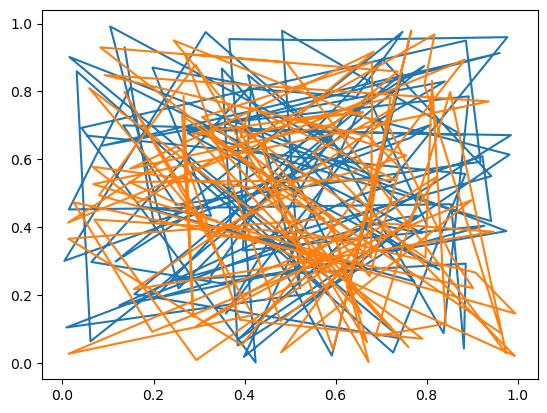

In [ ]:
import numpy as np
import similaritymeasures
import matplotlib.pyplot as plt

# Generate random experimental data
x = np.random.random(100)
y = np.random.random(100)
exp_data = np.zeros((100, 2))
exp_data[:, 0] = x
exp_data[:, 1] = y

# Generate random numerical data
x = np.random.random(100)
y = np.random.random(100)
num_data = np.zeros((100, 2))
num_data[:, 0] = x
num_data[:, 1] = y

# quantify the difference between the two curves using PCM
pcm = similaritymeasures.pcm(exp_data, num_data)

# quantify the difference between the two curves using
# Discrete Frechet distance
df = similaritymeasures.frechet_dist(exp_data, num_data)

# quantify the difference between the two curves using
# area between two curves
area = similaritymeasures.area_between_two_curves(exp_data, num_data)

# quantify the difference between the two curves using
# Curve Length based similarity measure
cl = similaritymeasures.curve_length_measure(exp_data, num_data)

# quantify the difference between the two curves using
# Dynamic Time Warping distance
dtw, d = similaritymeasures.dtw(exp_data, num_data)

# mean absolute error
mae = similaritymeasures.mae(exp_data, num_data)

# mean squared error
mse = similaritymeasures.mse(exp_data, num_data)

# print the results
print(pcm, df, area, cl, dtw, mae, mse)

# plot the data
plt.figure()
plt.plot(exp_data[:, 0], exp_data[:, 1])
plt.plot(num_data[:, 0], num_data[:, 1])
plt.show()

# Exporting data

In [ ]:
# hsa_df.to_csv("hsa_metrics.csv", index=False)
# print("Saved: hsa_metrics.csv")


# Analysis by HSA



# Analysis by State